In [2]:
import os
import yaml
from collections import defaultdict

# Base folder containing the subdirectories 0 to 7
base_dir = './alexnet_128/outputs'

# Accumulate energy per component and per action
energy_breakdown = defaultdict(lambda: defaultdict(float))

# Loop through directories 0 to 7
for i in range(8):
    folder = os.path.join(base_dir, str(i))
    ert_path = os.path.join(folder, 'timeloop-mapper.ERT_summary.yaml')
   
    if not os.path.isfile(ert_path):
        print(f"Warning: {ert_path} not found.")
        continue

    with open(ert_path, 'r') as file:
        ert_data = yaml.safe_load(file)

    # Parse ERT summary
    for component in ert_data.get('ERT_summary', {}).get('table_summary', []):
        name = component['name']
        for action in component.get('actions', []):
            action_name = action['name']
            energy = action['energy']
            energy_breakdown[name][action_name] += energy

# Print breakdown
print("Summed Energy Breakdown Across Layers:\n")
for comp_name, actions in energy_breakdown.items():
    print(f"{comp_name}:")
    for action_name, total_energy in actions.items():
        print(f"  {action_name:<10}: {total_energy:.6f}")
    print()

Summed Energy Breakdown Across Layers:

system_top_level.DRAM[1..1]:
  leak      : 0.000000
  update    : 4096.000000
  read      : 4096.000000
  write     : 4096.000000

system_top_level.weight_reg[1..16384]:
  leak      : 0.000000
  update    : 0.000000
  read      : 0.854560
  write     : 0.000000

system_top_level.input_activation_reg[1..16384]:
  leak      : 0.000000
  update    : 0.000000
  read      : 0.854560
  write     : 0.000000

system_top_level.output_activation_reg[1..16384]:
  leak      : 0.000000
  update    : 0.000000
  read      : 0.854560
  write     : 0.000000

system_top_level.shared_glb[1..1]:
  write     : 49.401200
  read      : 59.338000
  leak      : 0.156343
  update    : 49.401200

system_top_level.pe_spad[1..16384]:
  write     : 1.980152
  read      : 1.421000
  leak      : 0.000788
  update    : 1.980152

system_top_level.mac[1..16384]:
  compute   : 5.326144
  leak      : 0.036793



In [6]:
import os
import re

# Base directory
base_dir = './alexnet_128/outputs/'

# Data holder
layer_stats = []

total_cycles = 0

# Loop through directories 0 to 7
for i in range(8):
    folder = os.path.join(base_dir, str(i))
    stats_path = os.path.join(folder, 'timeloop-mapper.stats.txt')
   
    if not os.path.isfile(stats_path):
        print(f"Warning: {stats_path} not found.")
        continue

    with open(stats_path, 'r') as file:
        content = file.read()

    # Extract values using regex
    cycles_match = re.search(r'Cycles:\s+([0-9]+)', content)
    util_match = re.search(r'Utilization:\s+([\d.]+)%', content)
    computes_match = re.search(r'Computes\s*=\s*([0-9]+)', content)

    if cycles_match and util_match and computes_match:
        cycles = int(cycles_match.group(1))
        utilization = float(util_match.group(1))
        computes = int(computes_match.group(1))
        layer_stats.append((i, cycles, utilization, computes))
    else:
        print(f"Warning: Could not parse all values in {stats_path}")

# Print summary
print("Layer Summary (Cycles, Utilization %, Computes):\n")
for layer, cycles, util, computes in layer_stats:
    total_cycles += cycles
    print(f"Layer {layer}:")
    print(f"  Cycles      : {cycles}")
    print(f"  Utilization : {util}%")
    print(f"  Computes    : {computes}")
    print()

print(f"Total Cycles: {total_cycles}")

Layer Summary (Cycles, Utilization %, Computes):

Layer 0:
  Cycles      : 1585176
  Utilization : 0.27%
  Computes    : 70276800

Layer 1:
  Cycles      : 2615652
  Utilization : 0.52%
  Computes    : 223948800

Layer 2:
  Cycles      : 876096
  Utilization : 0.78%
  Computes    : 112140288

Layer 3:
  Cycles      : 1749488
  Utilization : 0.52%
  Computes    : 149520384

Layer 4:
  Cycles      : 1165424
  Utilization : 0.52%
  Computes    : 99680256

Layer 5:
  Cycles      : 294912
  Utilization : 0.78%
  Computes    : 37748736

Layer 6:
  Cycles      : 131072
  Utilization : 0.78%
  Computes    : 16777216

Layer 7:
  Cycles      : 32000
  Utilization : 0.78%
  Computes    : 4096000

Total Cycles: 8449820


In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Function to plot summed energy breakdown
def plot_energy_breakdown(energy_breakdown):
    # Convert to DataFrame and fill missing values
    energy_df = pd.DataFrame(energy_breakdown).fillna(0)

    # Clean column names by stripping 'system_top_level.'
    cleaned_columns = [name.replace("system_top_level.", "") for name in energy_df.columns]
    energy_df.columns = cleaned_columns

    # Plot with log scale
    ax = energy_df.T.plot(kind='bar', stacked=True, figsize=(14, 6))
    plt.yscale("log")
    plt.title("Summed Energy Breakdown Across Layers (Log Scale)")
    plt.ylabel("Energy (log scale)")
    plt.xlabel("Component")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Function to plot only cycles per layer
def plot_cycles_only(layer_stats):
    df = pd.DataFrame(layer_stats, columns=["Layer", "Cycles", "Utilization (%)", "Computes"])
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Cycles"], color='skyblue')
    plt.title("Cycles Breakdown per Layer")
    plt.xlabel("Layer")
    plt.ylabel("Cycles")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()


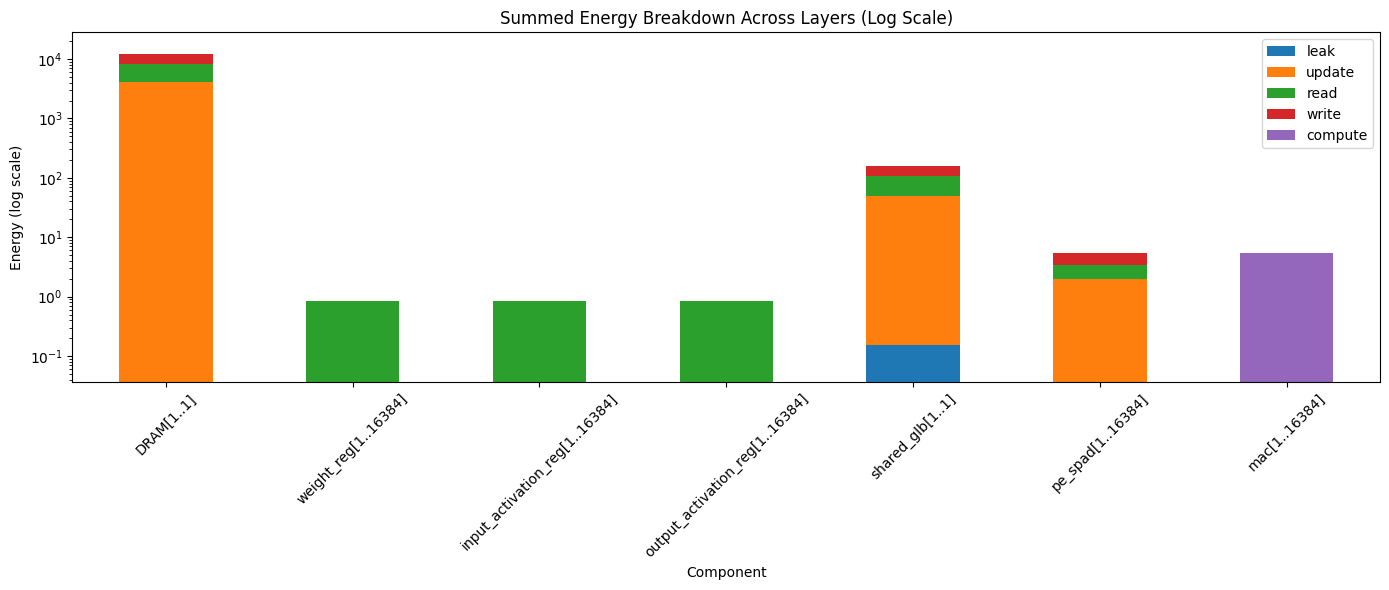

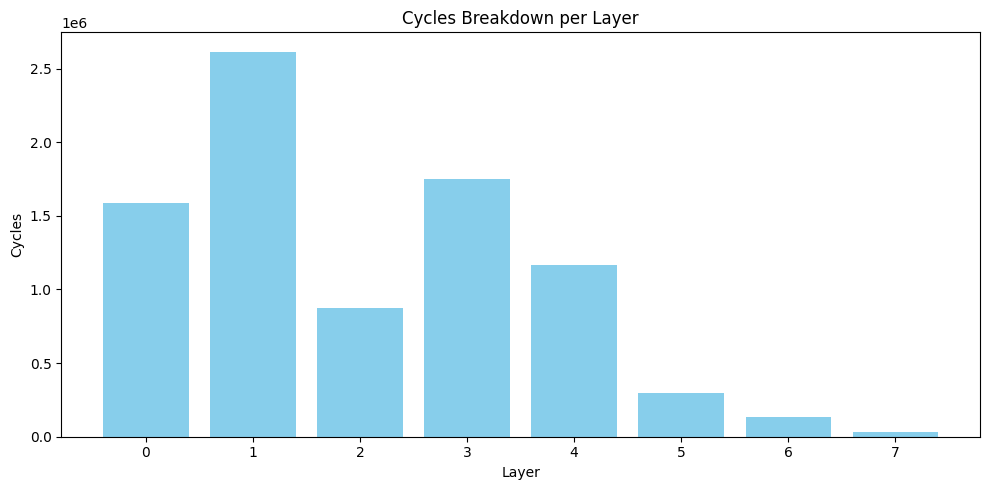

In [19]:
plot_energy_breakdown(energy_breakdown)
plot_cycles_only(layer_stats)

In [33]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print ("Model \t Energy/inference (J) \t Area (mm2) \t Throughput (inf/s)")

    energy = 0.0
    area = 0.0
    cycles = 0.0
    throughput = 0.0

    for subfolder in os.listdir(output_dir):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        # Parse energy and cycles
        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        energy += float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        cycles += float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        # Parse area only once (assume same design)
        if area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        area += count * area_per_unit
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")
                continue

    # Convert units
    energy *= 1e-6  # uJ to J
    area *= 1e-6    # um² to mm²
    throughput = 1 / (cycles * 1e-9) # s
    
    #print("Total energy/inference: {:.2e} J".format(energy))
    print ("{} \t {:.2e} \t {:.2f} \t {:.2e}".format(model, energy, area, throughput))
    return energy, area, throughput

# Example call
extract_outputs("alexnet", "alexnet_128")


Scanning in: ./alexnet_128/outputs
Model 	 Energy/inference (J) 	 Area (mm2) 	 Throughput (inf/s)
alexnet 	 9.17e-03 	 15.43 	 1.18e+02


(0.009168939999999999, 15.425409815999998, 118.34571624010925)

In [34]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Folder \tEnergy (J) \tCycles \t\tPartial Area (mm²)")

    total_energy = 0.0
    total_area = 0.0
    total_cycles = 0.0

    for subfolder in sorted(os.listdir(output_dir)):  # sorted for consistent order
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        folder_energy = 0.0
        folder_cycles = 0.0
        folder_area = 0.0

        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        folder_energy = float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        folder_cycles = float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        total_energy += folder_energy
        total_cycles += folder_cycles

        # Area only once (from the first available folder)
        if total_area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        folder_area += count * area_per_unit
                total_area = folder_area  # only assign once
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")

        # Print stats for current folder
        print(f"{model} \t {subfolder} \t{folder_energy * 1e-6:.2e} \t{int(folder_cycles)} \t\t{folder_area * 1e-6:.2f}")

    # Final conversion
    total_energy *= 1e-6  # uJ → J
    total_area *= 1e-6    # um² → mm²
    throughput = 1 / (total_cycles * 1e-9) if total_cycles > 0 else 0  # inf/s

    # Final summary
    print("\n=== Total Summary ===")
    print("Model \t\tEnergy/inference (J) \tArea (mm²) \tThroughput (inf/s)")
    print("{:s} \t{:.2e} \t\t{:.2f} \t\t{:.2e}".format(model, total_energy, total_area, throughput))

    return total_energy, total_area, throughput

# Example call
extract_outputs("alexnet", "alexnet_128")


Scanning in: ./alexnet_128/outputs
Model 	 Folder 	Energy (J) 	Cycles 		Partial Area (mm²)
alexnet 	 0 	1.85e-04 	1585176 		15.43
alexnet 	 1 	4.86e-04 	2615652 		0.00
alexnet 	 2 	2.74e-04 	876096 		0.00
alexnet 	 3 	3.91e-04 	1749488 		0.00
alexnet 	 4 	2.41e-04 	1165424 		0.00
alexnet 	 5 	4.89e-03 	294912 		0.00
alexnet 	 6 	2.17e-03 	131072 		0.00
alexnet 	 7 	5.31e-04 	32000 		0.00

=== Total Summary ===
Model 		Energy/inference (J) 	Area (mm²) 	Throughput (inf/s)
alexnet 	9.17e-03 		15.43 		1.18e+02


(0.009168939999999999, 15.425409815999998, 118.34571624010925)

In [41]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Folder \tEnergy (J) \tCycles")

    total_energy = 0.0
    total_cycles = 0.0
    total_area = 0.0

    layer_data = []  # For plotting

    for subfolder in sorted(os.listdir(output_dir)):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        folder_energy = 0.0
        folder_cycles = 0.0

        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        folder_energy = float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        folder_cycles = float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        total_energy += folder_energy
        total_cycles += folder_cycles

        # Area only once
        if total_area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        total_area += count * area_per_unit
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")

        print(f"{model} \t {subfolder} \t{folder_energy * 1e-6:.2e} \t{int(folder_cycles)}")

        # Save for plotting
        layer_data.append({
            "Layer": int(subfolder),
            "Energy (uJ)": folder_energy,
            "Cycles": folder_cycles
        })

    # Summary
    total_energy *= 1e-6
    total_area *= 1e-6
    throughput = 1 / (total_cycles * 1e-9) if total_cycles > 0 else 0

    print("\n=== Total Summary ===")
    print("Model \t\tEnergy/inference (J) \tArea (mm²) \tThroughput (inf/s)")
    print("{:s} \t{:.2e} \t\t{:.2f} \t\t{:.2e}".format(model, total_energy, total_area, throughput))

    return layer_data


In [42]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_energy_and_cycles_per_layer(layer_data):
    df = pd.DataFrame(layer_data).sort_values("Layer")

    # Plot Energy
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Energy (uJ)"], color='mediumseagreen')
    plt.title("Energy per Layer")
    plt.xlabel("Layer")
    plt.ylabel("Energy (uJ)")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()

    # Plot Cycles
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Cycles"], color='steelblue')
    plt.title("Cycles per Layer")
    plt.xlabel("Layer")
    plt.ylabel("Cycles")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()


Scanning in: ./alexnet_128/outputs
Model 	 Folder 	Energy (J) 	Cycles
alexnet 	 0 	1.85e-04 	1585176
alexnet 	 1 	4.86e-04 	2615652
alexnet 	 2 	2.74e-04 	876096
alexnet 	 3 	3.91e-04 	1749488
alexnet 	 4 	2.41e-04 	1165424
alexnet 	 5 	4.89e-03 	294912
alexnet 	 6 	2.17e-03 	131072
alexnet 	 7 	5.31e-04 	32000

=== Total Summary ===
Model 		Energy/inference (J) 	Area (mm²) 	Throughput (inf/s)
alexnet 	9.17e-03 		15.43 		1.18e+02


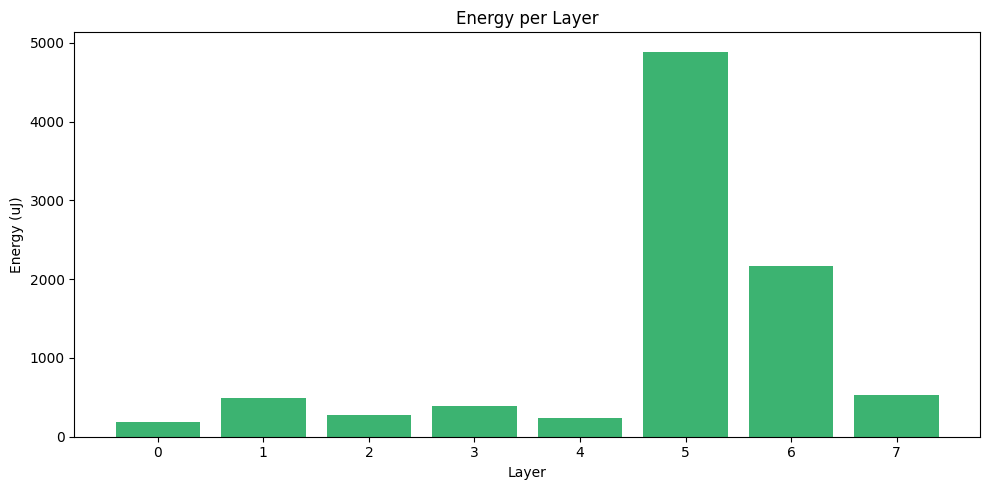

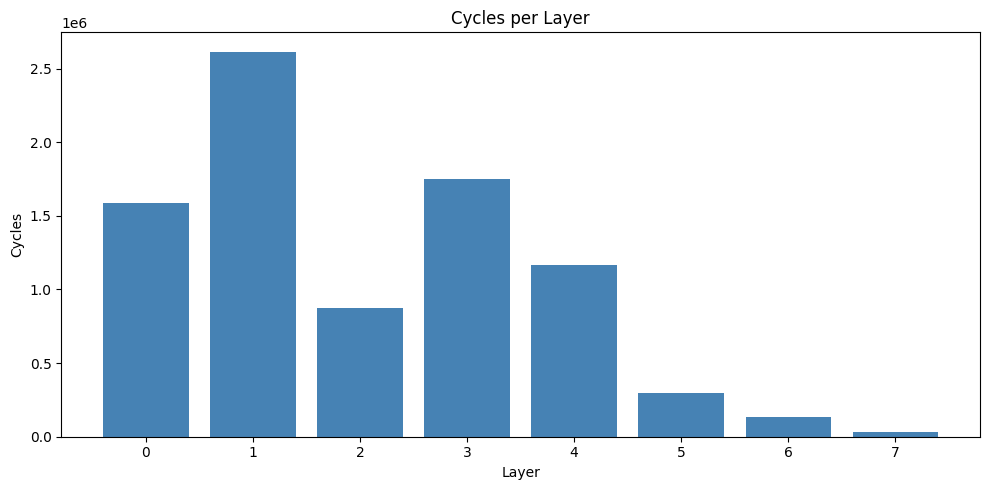

In [43]:
layer_data = extract_outputs("alexnet", "alexnet_128")
plot_energy_and_cycles_per_layer(layer_data)


In [38]:
import os
import yaml
from collections import defaultdict

# Base folder containing the subdirectories 0 to 7
base_dir = './alexnet_128/outputs'

# Store energy breakdown per layer: {layer -> {component -> energy}}
layer_component_energy = defaultdict(lambda: defaultdict(float))

# Loop through directories 0 to 7
for i in range(8):
    folder = os.path.join(base_dir, str(i))
    ert_path = os.path.join(folder, 'timeloop-mapper.ERT_summary.yaml')
   
    if not os.path.isfile(ert_path):
        print(f"Warning: {ert_path} not found.")
        continue

    with open(ert_path, 'r') as file:
        ert_data = yaml.safe_load(file)

    # Parse ERT summary
    for component in ert_data.get('ERT_summary', {}).get('table_summary', []):
        name = component['name']
        total_component_energy = 0.0
        for action in component.get('actions', []):
            total_component_energy += action['energy']
        layer_component_energy[i][name] += total_component_energy

# Compute and print per-layer energy breakdown
print("\nPer-Layer Energy Breakdown by Component (absolute and %):\n")

for layer in sorted(layer_component_energy):
    component_data = layer_component_energy[layer]
    total_layer_energy = sum(component_data.values())
    print(f"Layer {layer} - Total Energy: {total_layer_energy:.6f} uJ")

    for component, energy in component_data.items():
        percent = (energy / total_layer_energy) * 100 if total_layer_energy > 0 else 0
        print(f"  {component:<35} : {energy:.6f} uJ ({percent:.2f}%)")
    print()



Per-Layer Energy Breakdown by Component (absolute and %):

Layer 0 - Total Energy: 1557.450682 uJ
  system_top_level.DRAM[1..1]         : 1536.000000 uJ (98.62%)
  system_top_level.weight_reg[1..16384] : 0.106820 uJ (0.01%)
  system_top_level.input_activation_reg[1..16384] : 0.106820 uJ (0.01%)
  system_top_level.output_activation_reg[1..16384] : 0.106820 uJ (0.01%)
  system_top_level.shared_glb[1..1]   : 19.787093 uJ (1.27%)
  system_top_level.pe_spad[1..16384]  : 0.672762 uJ (0.04%)
  system_top_level.mac[1..16384]      : 0.670367 uJ (0.04%)

Layer 1 - Total Energy: 1557.450682 uJ
  system_top_level.DRAM[1..1]         : 1536.000000 uJ (98.62%)
  system_top_level.weight_reg[1..16384] : 0.106820 uJ (0.01%)
  system_top_level.input_activation_reg[1..16384] : 0.106820 uJ (0.01%)
  system_top_level.output_activation_reg[1..16384] : 0.106820 uJ (0.01%)
  system_top_level.shared_glb[1..1]   : 19.787093 uJ (1.27%)
  system_top_level.pe_spad[1..16384]  : 0.672762 uJ (0.04%)
  system_top_leve

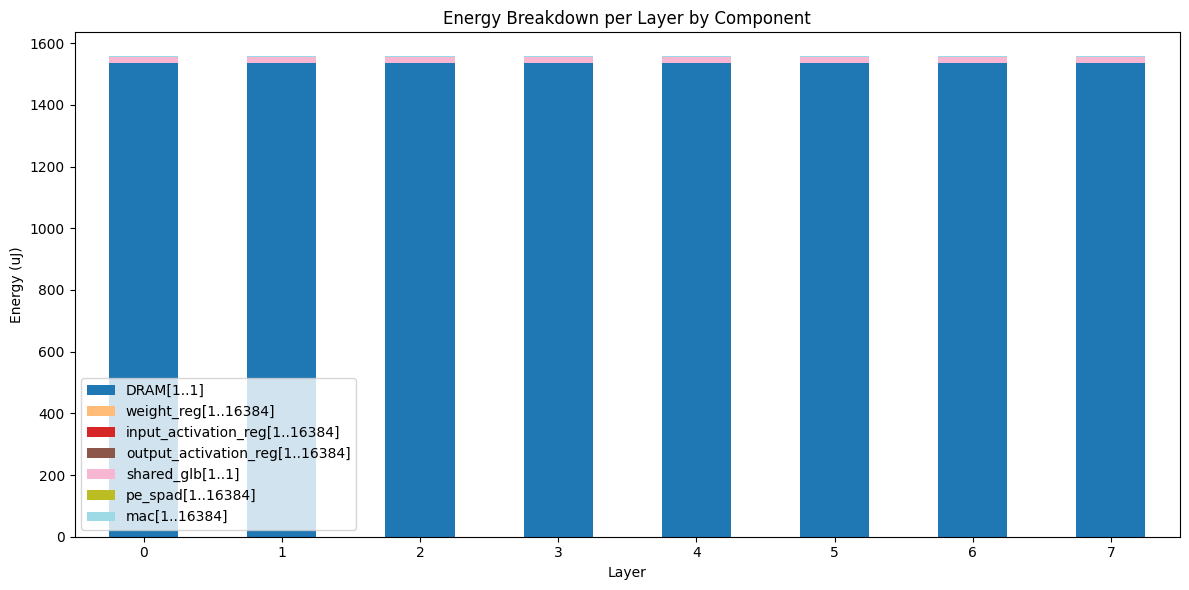

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
df = pd.DataFrame(layer_component_energy).T.fillna(0)  # layers as rows, components as columns

# Optional: clean component names (remove 'system_top_level.')
df.columns = [col.replace("system_top_level.", "") for col in df.columns]

# Plot
df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title("Energy Breakdown per Layer by Component")
plt.xlabel("Layer")
plt.ylabel("Energy (uJ)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [45]:
# Total energy per component across all layers
total_component_energy = defaultdict(float)

for layer_data in layer_component_energy.values():
    for component, energy in layer_data.items():
        total_component_energy[component] += energy

total_energy = sum(total_component_energy.values())

print("=== Total Component Energy Breakdown Across All Layers ===")
for component, energy in sorted(total_component_energy.items(), key=lambda x: -x[1]):
    percent = (energy / total_energy) * 100 if total_energy > 0 else 0
    print(f"{component:<35} : {energy:.6f} uJ ({percent:.2f}%)")


=== Total Component Energy Breakdown Across All Layers ===
system_top_level.DRAM[1..1]         : 12288.000000 uJ (98.62%)
system_top_level.shared_glb[1..1]   : 158.296743 uJ (1.27%)
system_top_level.pe_spad[1..16384]  : 5.382092 uJ (0.04%)
system_top_level.mac[1..16384]      : 5.362937 uJ (0.04%)
system_top_level.weight_reg[1..16384] : 0.854560 uJ (0.01%)
system_top_level.input_activation_reg[1..16384] : 0.854560 uJ (0.01%)
system_top_level.output_activation_reg[1..16384] : 0.854560 uJ (0.01%)
